In [11]:
import MDAnalysis as mda
from MDAnalysis.transformations import unwrap, center_in_box
import os
import numpy as np
import freud
import matplotlib.pyplot as plt
import tqdm

In [12]:
lipids = 4096

In [13]:
def block_analysis(data, max_size = 10000):

    data = np.array(data)
    n = len(data)

    block_size = 10
    blocking_errors = []
    block_sizes = []

    while block_size <= min(max_size, n//2):

        n_blocks = n // block_size

        n_use = n_blocks * block_size
        data_trimmed = data[:n_use]

        blocks = data_trimmed.reshape(n_blocks, block_size)
        block_means = np.mean(blocks, axis=1)
        std_error = np.std(block_means, ddof=1) / np.sqrt(n_blocks)

        blocking_errors.append(std_error)
        block_sizes.append(block_size)

        block_size += 10

    plt.figure(figsize=(8, 5))
    plt.plot(block_sizes, blocking_errors, 'o-')
    plt.xlabel('Block Size')
    plt.ylabel('Standard Error')
    plt.grid(True)
    plt.title('Block Analysis')

    plt.show()
    
    return block_sizes, blocking_errors

In [14]:
def running_avg(lst):

    avg_lst = []
    std_lst = []

    for i in tqdm.tqdm(range(len(lst))):

       avg_lst.append(np.mean(lst[:i+1])) 
       std_lst.append(np.std(lst[:i+1]))

    avg_lst, std_lst = np.array(avg_lst), np.array(std_lst)

    plt.plot(avg_lst)

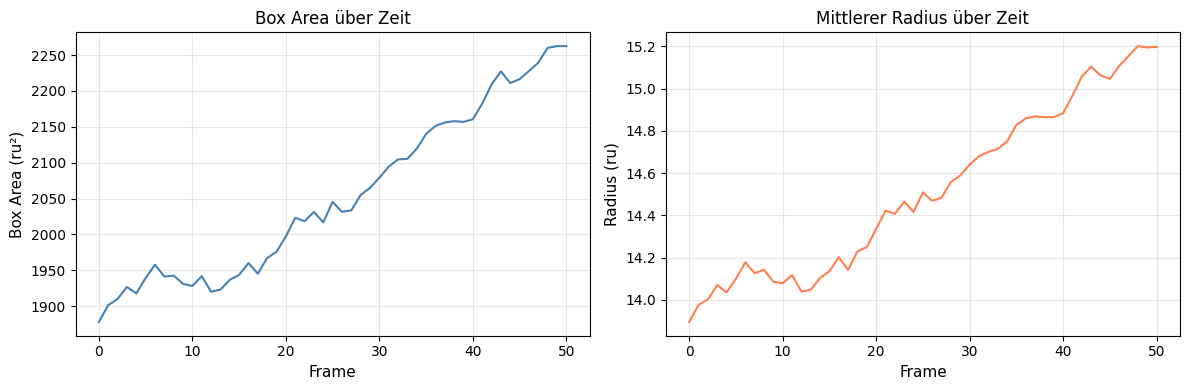

Values for R = 8
Force -1.684659383512853
Force per sigma -1.7350218539890536
kappa = -3.892361351652448


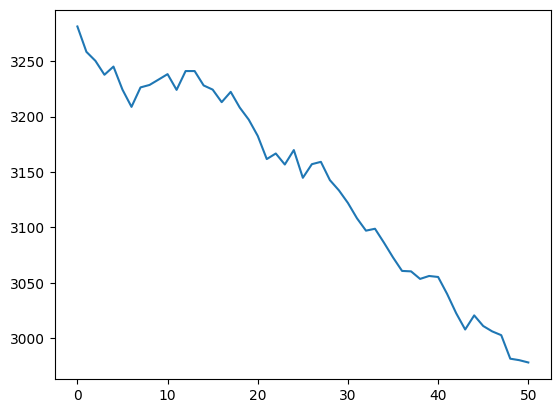

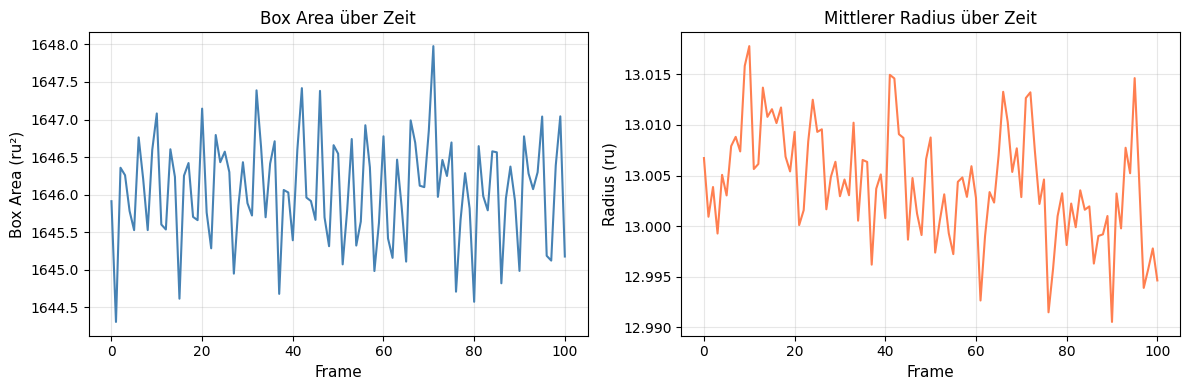

Values for R = 8_other_bar
Force -15.442142370609574
Force per sigma -15.442167131905299
kappa = -31.96056439411772


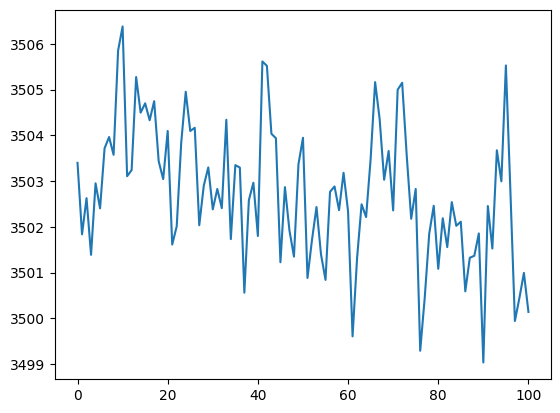

In [15]:
dir = "/home/gabriel/Dokumente/bachelor_thesis/dpd_simulation/bending_modulus/"

rads = ["8", "8_other_bar"]

for R in rads:

    sigma_data = np.loadtxt(os.path.join(dir, f"tether_simulation/data/stress_and_force_{R}.dat"), skiprows=2, usecols=(1,2,3,4))
    sigma_xx, sigma_yy, sigma_zz, force_z = sigma_data[:, 0], sigma_data[:, 1], sigma_data[:, 2], sigma_data[:, 3]

    top_file = os.path.join(dir, f"setup/cylinder_8.data")
    traj_file = os.path.join(dir, f"tether_simulation/data/cylinder_sim_{R}.lammpstrj")

    u = mda.Universe(top_file, format="DATA", atom_style = "id resid type charge x y z")
    u.load_new(traj_file, format="LAMMPSDUMP", dt=0.005)

    radii = []
    box = []
    box_z = []

    lipid_atoms = u.select_atoms(f"not type 4")

    for ts in u.trajectory:

        com = lipid_atoms.center_of_mass()

        positions = lipid_atoms.positions

        x = positions[:, 0] - com[0]
        y = positions[:, 1] - com[1]

        r = np.sqrt(x**2 + y**2)

        radii.append(np.mean(r))
        box.append(np.prod(ts.dimensions[:2]))
        box_z.append(ts.dimensions[2])

    radius = np.mean(radii)
    area = np.mean(box)

    radii, box, box_z = np.array(radii), np.array(box), np.array(box_z)

    cyl_area = 2*np.pi*radii*box_z

    force = np.mean(force_z)
    force_sigma = np.mean(sigma_zz)*area

    kappa = force*radius/(2*np.pi)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(box, linewidth=1.5, color='steelblue')
    axes[0].set_xlabel('Frame', fontsize=11)
    axes[0].set_ylabel('Box Area (ru²)', fontsize=11)
    axes[0].set_title('Box Area über Zeit', fontsize=12)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(radii, linewidth=1.5, color='coral')
    axes[1].set_xlabel('Frame', fontsize=11)
    axes[1].set_ylabel('Radius (ru)', fontsize=11)
    axes[1].set_title('Mittlerer Radius über Zeit', fontsize=12)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Values for R = {R}")
    print(f"Force {force}")
    print(f"Force per sigma {force_sigma}")

    plt.plot(cyl_area)

    print(f"kappa = {kappa}")